In [2]:
# ----------- MOUNT DRIVE ----------
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ----------- IMPORTS ----------
import os
import torch

# ----------- GPU CHECK ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", device)

# ----------- PATHS ----------
BASE = "/content/drive/MyDrive/coco20k"
TRAIN_IMG = f"{BASE}/train/images"
TRAIN_MASK = f"{BASE}/train/masks"
VAL_IMG   = f"{BASE}/val/images"
VAL_MASK  = f"{BASE}/val/masks"

print("Train images:", len(os.listdir(TRAIN_IMG)))
print("Val images:", len(os.listdir(VAL_IMG)))


Mounted at /content/drive
DEVICE: cpu
Train images: 29256
Val images: 7334


In [3]:
import os, cv2, numpy as np, random
from torch.utils.data import Dataset, DataLoader

IMG_SIZE = 128

class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, limit=None, augment=False):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.augment = augment

        self.files = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])
        if limit:
            self.files = self.files[:limit]

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]

        img = cv2.imread(f"{self.img_dir}/{name}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        mask = cv2.imread(f"{self.mask_dir}/{name.replace('.jpg','.png')}", 0)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        mask = (mask > 0).astype(np.float32)

        if self.augment and random.random() > 0.5:
            img = np.fliplr(img).copy()
            mask = np.fliplr(mask).copy()

        img = np.transpose(img.astype(np.float32)/255, (2,0,1))
        mask = np.expand_dims(mask, 0)

        return torch.tensor(img), torch.tensor(mask)


In [4]:
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.c = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.ReLU()
        )
    def forward(self, x): return self.c(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.d1 = DoubleConv(3, 64)
        self.d2 = DoubleConv(64, 128)
        self.d3 = DoubleConv(128, 256)
        self.d4 = DoubleConv(256, 512)
        self.bott = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.u4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.u3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.u2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.u1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        c1 = self.d1(x); p1 = nn.MaxPool2d(2)(c1)
        c2 = self.d2(p1); p2 = nn.MaxPool2d(2)(c2)
        c3 = self.d3(p2); p3 = nn.MaxPool2d(2)(c3)
        c4 = self.d4(p3); p4 = nn.MaxPool2d(2)(c4)

        c5 = self.bott(p4)

        u4 = self.up4(c5); u4 = self.u4(torch.cat([u4, c4], 1))
        u3 = self.up3(u4); u3 = self.u3(torch.cat([u3, c3], 1))
        u2 = self.up2(u3); u2 = self.u2(torch.cat([u2, c2], 1))
        u1 = self.up1(u2); u1 = self.u1(torch.cat([u1, c1], 1))

        return self.out(u1)


In [5]:
bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target, eps=1e-6):
    pred = torch.sigmoid(pred)
    inter = (pred*target).sum()
    union = pred.sum() + target.sum()
    return 1 - (2*inter+eps)/(union+eps)

def train_epoch(model, loader, opt):
    model.train(); total = 0
    for img, mask in loader:
        img, mask = img.to(device), mask.to(device)
        opt.zero_grad()
        out = model(img)
        loss = bce(out, mask) + dice_loss(out, mask)
        loss.backward()
        opt.step()
        total += loss.item()
    return total / len(loader)

def val_epoch(model, loader):
    model.eval(); total = 0
    with torch.no_grad():
        for img, mask in loader:
            img, mask = img.to(device), mask.to(device)
            out = model(img)
            loss = bce(out, mask) + dice_loss(out, mask)
            total += loss.item()
    return total / len(loader)


In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.c = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, 1, 1), nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1), nn.ReLU()
        )
    def forward(self, x):
        return self.c(x)

class UNetLite(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = DoubleConv(3,32)
        self.d2 = DoubleConv(32,64)
        self.d3 = DoubleConv(64,128)
        self.bott = DoubleConv(128,256)

        self.up3 = nn.ConvTranspose2d(256,128,2,2)
        self.u3  = DoubleConv(256,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.u2  = DoubleConv(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.u1  = DoubleConv(64,32)

        self.out = nn.Conv2d(32,1,1)

    def forward(self, x):
        c1 = self.d1(x); p1 = nn.MaxPool2d(2)(c1)
        c2 = self.d2(p1); p2 = nn.MaxPool2d(2)(c2)
        c3 = self.d3(p2); p3 = nn.MaxPool2d(2)(c3)
        c4 = self.bott(p3)

        u3 = self.up3(c4)
        u3 = self.u3(torch.cat([u3, c3], 1))

        u2 = self.up2(u3)
        u2 = self.u2(torch.cat([u2, c2], 1))

        u1 = self.up1(u2)
        u1 = self.u1(torch.cat([u1, c1], 1))

        return self.out(u1)


In [10]:
# =============================
# IMPORT OPTIMIZER
# =============================
import torch.optim as optim

# =============================
# LOAD DATA (FAST MODE)
# =============================

train_ds = SegDataset(TRAIN_IMG, TRAIN_MASK, augment=True)
val_ds   = SegDataset(VAL_IMG, VAL_MASK)

train_ds.files = train_ds.files[:1000]
val_ds.files   = val_ds.files[:200]

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


# =============================
# TRAIN MODEL
# =============================

model = UNetLite().to(device)
opt = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 5
train_loss = []
val_loss = []

print("\nTraining started...\n")

for ep in range(EPOCHS):
    tr = train_epoch(model, train_loader, opt)
    vl = val_epoch(model, val_loader)

    train_loss.append(tr)
    val_loss.append(vl)

    print(f"Epoch {ep+1}/{EPOCHS} | Train: {tr:.4f} | Val: {vl:.4f}")


# =============================
# SAVE MODEL
# =============================

save_path = "/content/drive/MyDrive/unet_task4_fast_final.pth"
torch.save(model.state_dict(), save_path)

print("MODEL SAVED AT:", save_path)


Train batches: 125
Val batches: 25

Training started...

Epoch 1/5 | Train: 1.3009 | Val: 1.2624
Epoch 2/5 | Train: 1.2381 | Val: 1.2042
Epoch 3/5 | Train: 1.1686 | Val: 1.1046
Epoch 4/5 | Train: 1.1215 | Val: 1.0576
Epoch 5/5 | Train: 1.0916 | Val: 1.0347
MODEL SAVED AT: /content/drive/MyDrive/unet_task4_fast_final.pth


In [11]:
import torch
import numpy as np

model.eval()

iou_list = []
dice_list = []
acc_list = []

def iou(pred, gt, eps=1e-6):
    inter = (pred * gt).sum()
    union = pred.sum() + gt.sum() - inter
    return (inter + eps) / (union + eps)

def dice(pred, gt, eps=1e-6):
    inter = (pred * gt).sum()
    return (2*inter + eps) / (pred.sum() + gt.sum() + eps)

def pixel_acc(pred, gt):
    return (pred == gt).mean()

print("\nCalculating accuracy on 10 samples...\n")

with torch.no_grad():
    for i in range(10):        # FAST MODE
        img, mask = val_ds[i]
        img_t = img.unsqueeze(0).to(device)

        pred = torch.sigmoid(model(img_t))[0,0].cpu().numpy()
        pred_bin = (pred > 0.5).astype(np.uint8)

        mask_np = mask.squeeze().numpy().astype(np.uint8)

        iou_list.append(iou(pred_bin, mask_np))
        dice_list.append(dice(pred_bin, mask_np))
        acc_list.append(pixel_acc(pred_bin, mask_np))

print("========= ACCURACY REPORT =========")
print("Mean IoU:        ", round(np.mean(iou_list), 4))
print("Mean Dice Score: ", round(np.mean(dice_list), 4))
print("Pixel Accuracy:  ", round(np.mean(acc_list), 4))
print("===================================")



Calculating accuracy on 10 samples...

========= ACCURACY REPORT =========
Mean IoU:         0.3878
Mean Dice Score:  0.5349
Pixel Accuracy:   0.705


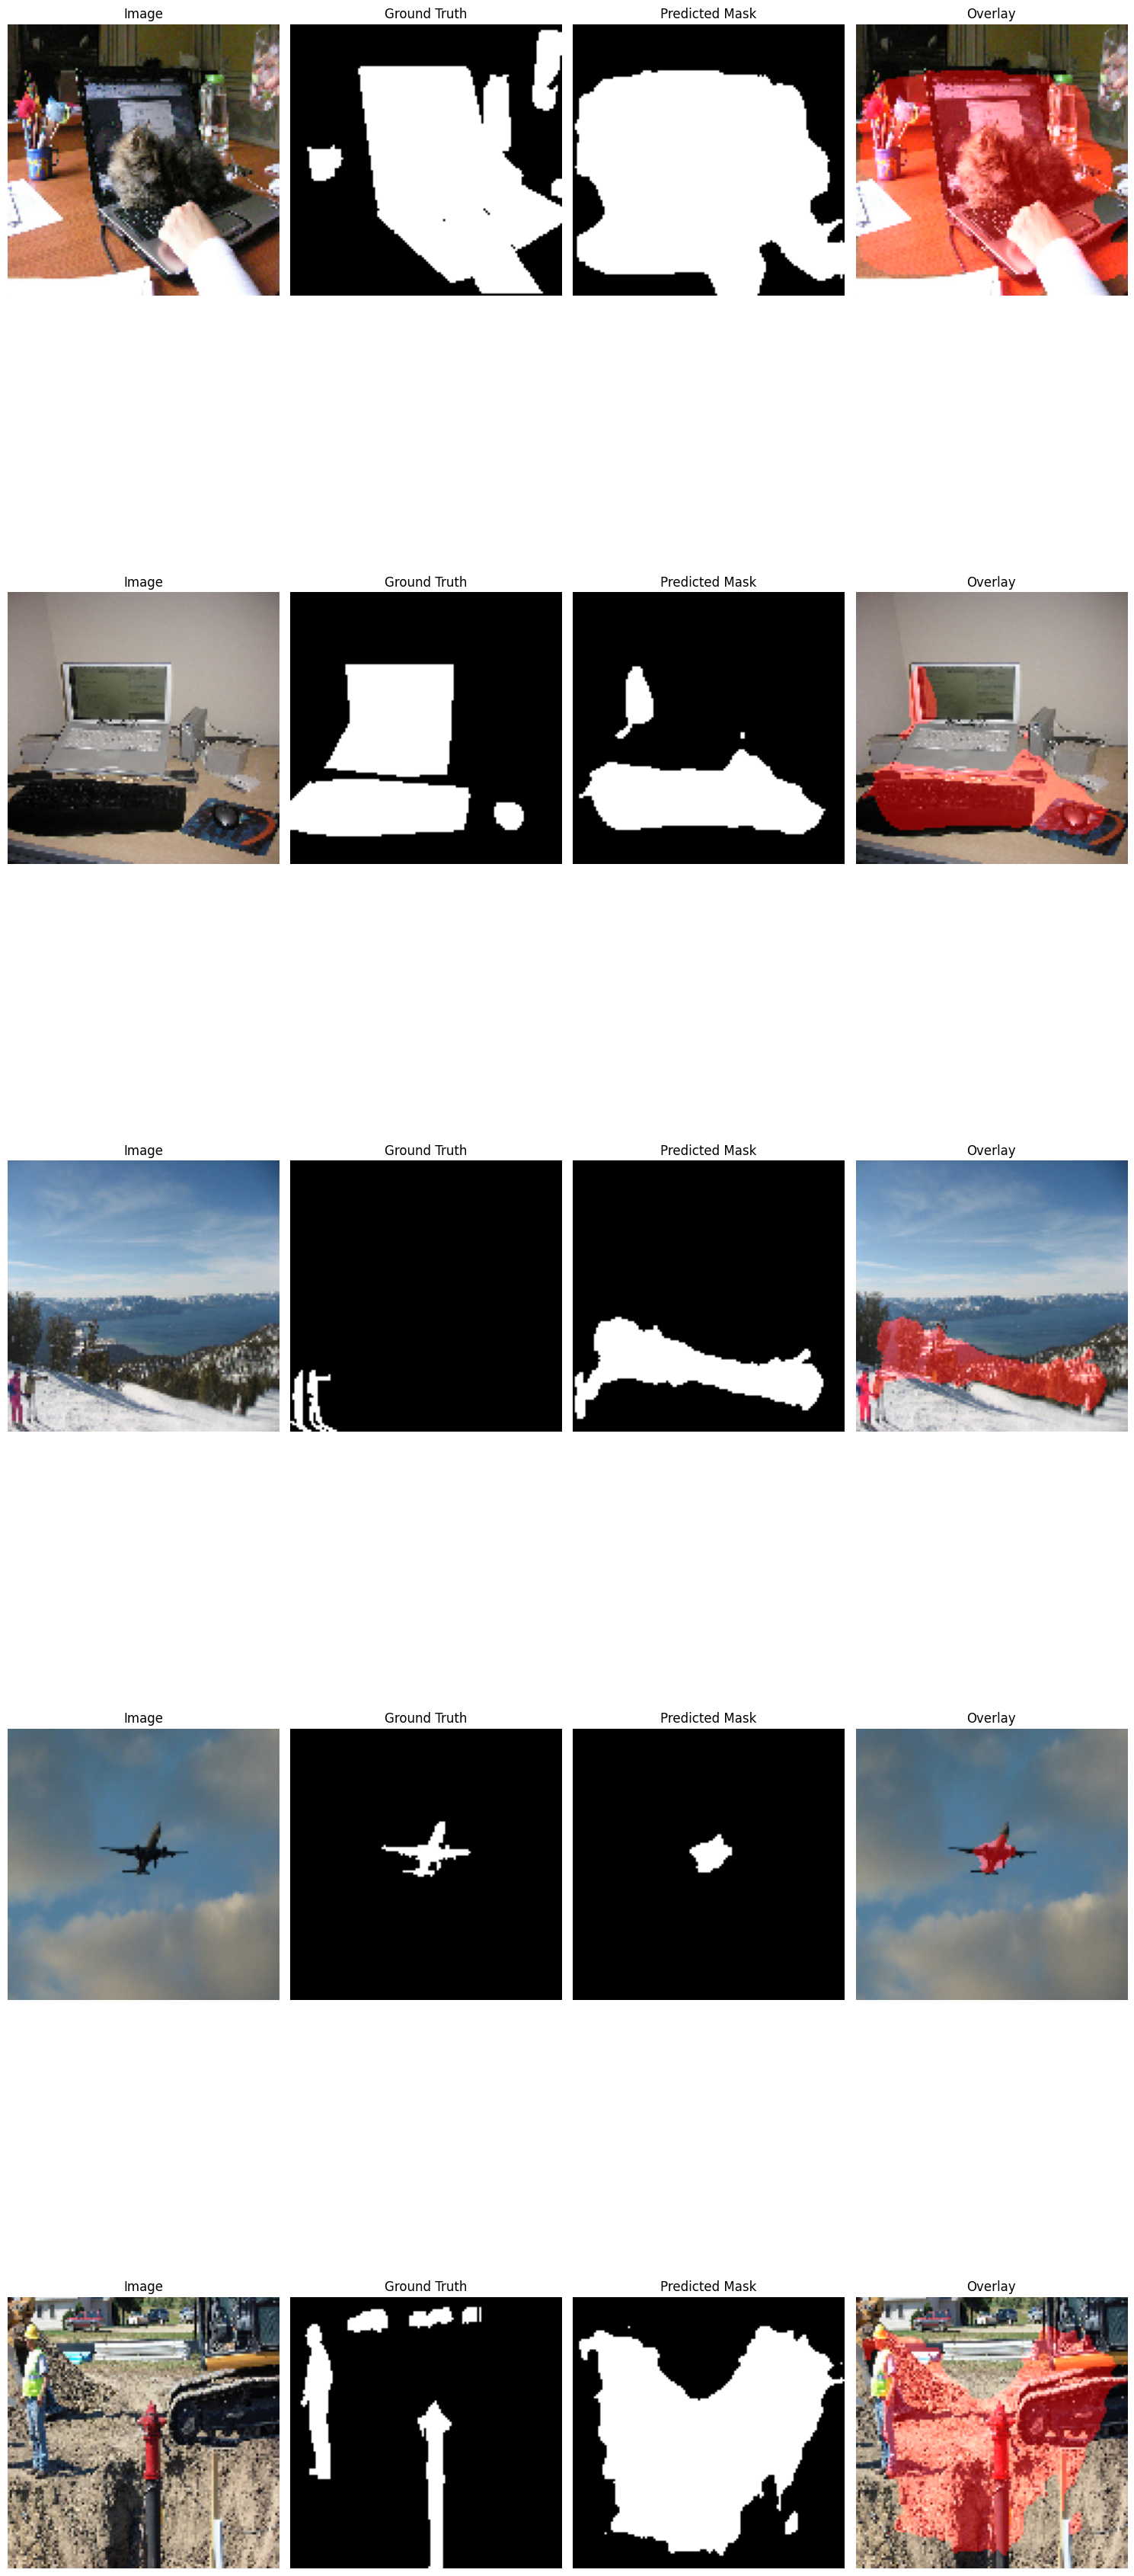

In [12]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

model.eval()

plt.figure(figsize=(15,40))
k = 1

for i in range(5):   # 5 samples for output
    img, mask = val_ds[i]
    img_t = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = torch.sigmoid(model(img_t))[0,0].cpu().numpy()

    pred_bin = (pred > 0.5).astype("uint8")

    base = (img.permute(1,2,0).numpy()*255).astype("uint8")
    over_mask = np.zeros_like(base)
    over_mask[:,:,0] = pred_bin * 255
    overlay = cv2.addWeighted(base, 1, over_mask, 0.5, 0)

    plt.subplot(5,4,k); k+=1
    plt.imshow(base); plt.title("Image"); plt.axis("off")

    plt.subplot(5,4,k); k+=1
    plt.imshow(mask[0], cmap="gray"); plt.title("Ground Truth"); plt.axis("off")

    plt.subplot(5,4,k); k+=1
    plt.imshow(pred_bin, cmap="gray"); plt.title("Predicted Mask"); plt.axis("off")

    plt.subplot(5,4,k); k+=1
    plt.imshow(overlay); plt.title("Overlay"); plt.axis("off")

plt.tight_layout()
plt.show()
